# Notes

$ T_c = 2.269 $

The convergence time is much longer closer to the critical point I think

We may need the wolff algorithm:
http://latt.if.usp.br/technical-pages/twawesab/Text.html/node1.html

# The data we need

In https://arxiv.org/pdf/1606.00318.pdf : 
- They do 100 independant snapshots per temperature
- They did L=20,40,80 and only 80 had properly good results

In https://journals.aps.org/pre/pdf/10.1103/PhysRevE.95.062122:
- 40 temperatures from 2.0 to 2.8
- They generate 10,000 INDEPENDANT snapshots

In the potts model PCA report:
- They skipped many sweeps between snapshots so that the snapshots are all independant. 
- They took about 500 snapshots per temperature. 
- Thus, we don't need to take many snapshots, we just need to make them independant.
- They did this for 20 temperatures around Tc: roughly in the interval: [1.8, 2.8]

### Based on this I might aswell just do one snapshot per random config and use alot of burn sweeps

Should probably quantify convergence to justify the number of burn sweeps being used.

<b>The only reason to not do this would be if the number of intermediate sweeps to guarantee independance is significantly less than the number of burn sweeps to guarantee convergence. </b>

In [65]:
import numpy as np  # package for arrays
import matplotlib.pyplot as plt  # package for plotting
import time  # for timing
import random as ran
from time import time
# display plots inside of notebook
%matplotlib inline

Tc = 2.269

In [66]:
class Ising:
    
    def __init__(self, shape: tuple, J, x):

        self.J = J
        self.x = x
        self.shape = shape
        self.dim = len(shape) # dimensionality
        
        self.N = 1
        for e in shape:
            self.N *= e
        
        # lattice state
        self.n_missing = round(self.N*x)
        self.n_occupied = self.N - self.n_missing
        
        spins = [0 for _ in range(self.n_missing)] + [ran.choice([-1,1]) for _ in range(self.n_occupied)]
        flattened_state = np.array(ran.sample(spins, len(spins)))
        self.lattice_state = np.reshape(flattened_state, self.shape)
        
        # occupied indices
        occupied_indices = []
        for i,row in enumerate(self.lattice_state):
            for j,spin in enumerate(row):
                if spin:
                    occupied_indices.append((i,j))
                    
        self.occupied_sites = occupied_indices
        self.N_spins = len(occupied_indices) # number of spins
        
    def init_up(self): # randomise lattice with 75% up spins
        n_up = round(self.n_occupied*0.75)
        n_down = self.n_occupied - n_up
        spins = [0 for _ in range(self.n_missing)] + [1 for _ in range(n_up)] + [-1 for _ in range(n_down)]
        flattened_state = np.array(ran.sample(spins, len(spins)))
        self.lattice_state = np.reshape(flattened_state, self.shape)
        occupied_indices = []
        for i,row in enumerate(self.lattice_state):
            for j,spin in enumerate(row):
                if spin:
                    occupied_indices.append((i,j))
        self.occupied_sites = occupied_indices
        
    def init_down(self): # randomise lattice with 75% down spins
        n_down = round(self.n_occupied*0.75)
        n_up = self.n_occupied - n_down
        spins = [0 for _ in range(self.n_missing)] + [1 for _ in range(n_up)] + [-1 for _ in range(n_down)]
        flattened_state = np.array(ran.sample(spins, len(spins)))
        self.lattice_state = np.reshape(flattened_state, self.shape)
        occupied_indices = []
        for i,row in enumerate(self.lattice_state):
            for j,spin in enumerate(row):
                if spin:
                    occupied_indices.append((i,j))
        self.occupied_sites = occupied_indices
        
    def take_snapshot(self):
        return self.lattice_state.copy()
    
    def set_lattice(self, state):
        self.lattice_state = state
    
    def flip_spin(self, s_new, index: tuple):
        self.lattice_state[index] = s_new
        
    def calculate_energy_of_spin(self, index):
        """
        Periodic boundary conditions implemented
        """
        
        spin_here = self.lattice_state[index]  # value of spin here
        
        NN_spins = []
        
        index = index
        
        # looping over each dimension
        for i,e in enumerate(index):
            
            NN1 = list(index)
            if e == self.shape[i]-1: # if at the end boundary apply periodic boundary conditions
                NN1[i] = 0
            else:
                NN1[i] = e+1
            
            NN2 = list(index)
            NN2[i] = e-1
            
            NN_spins.append(self.lattice_state[tuple(NN1)])
            NN_spins.append(self.lattice_state[tuple(NN2)])
        
        E = 0
        for spin in NN_spins:
            E -= self.J*spin*spin_here
            
        return E
    
    def magnetization(self): # magnetisation is just the sum of all spins / N
        return np.sum(self.lattice_state)/self.N_spins
    
    def flip_trial(self, kT):

        # generate random index
        index = ran.choice(self.occupied_sites)

        # old spin and proposed new spin
        s_old = self.lattice_state[index]
        s_trial = s_old*-1

        # Calculate current energy of spin
        E_old = self.calculate_energy_of_spin(index)

        # Propose flip
        self.flip_spin(s_trial, index)

        # Calculate new energy of spin
        E_new = self.calculate_energy_of_spin(index)

        # Probability of accepting
        P =  np.exp(-(E_new - E_old) / kT)

        if ran.random() > P : #reject
            self.flip_spin(s_old, index) # flip spin back
            return 0

        return 1

    def sweep_lattice(self, kT):
        for e in range(self.N_spins):
            self.flip_trial(kT)
    
    def run_N_trials(self, N, kT):
        snapshots = []
        for e in range(N):
            self.flip_trial(kT)
            snapshots.append(self.take_snapshot())
        return snapshots
            
    def run_N_sweeps(self, N, kT):
        for e in range(N):
            self.sweep_lattice(kT)
            
    def test_convergence(self, N, kT):
        m = []
        for e in range(N):
            self.flip_trial(kT)
            m.append(self.magnetization())
        return m

   

In [67]:
def magnetisation(state):
    N = np.count_nonzero(state)
    return np.sum(state)/N

def flatten_states(states):
    '''
    states must have the shape: (n_states, dimension1, dimension2, ... )
    '''
    shape = states.shape
    n_states = shape[0]
    N = np.prod(np.array(list(shape)[1:]))
    newshape = (n_states, N)
    
    return np.reshape(states, newshape)

def m_from_states(states):
    m = []
    for state in states:
        m.append(magnetisation(state))
    return np.array(m)

def mean_absolute(value, y, central_limit=True):
    temperatures = list(set(y))
    
    means = []
    errs = []
    for kT in temperatures:
        filt = y==kT
        samples = value[filt]
        N_samples = len(samples)
        
        samples = np.abs(samples)
        mean = np.mean(samples)
        if central_limit:
            err = np.std(samples)/np.sqrt(N_samples)
        else:
            err = np.std(samples)
        
        errs.append(err)
        means.append(mean)
        
    return means, errs, temperatures

There may be a different 'mean absolute' i have to use: For each T: take mean of all the init_up states and separately take mean of all the init_down states. Then take the absolute of these means then average them together. 

# Testing convergence

1. MOST IMPORTANT: test how many sweeps it takes for the average to converge
2. Test how many trials/sweeps the magnetisation takes to converge
3. Test this at different temperatures. Will take longer closer to critical T

In [128]:
model = Ising(shape=(40,40), J=1, x=0)
model.init_up()

N_sweeps = 6000
N_trials = N_sweeps*model.N_spins

t1 = time()

kT = 2.2
m = model.test_convergence(N=N_trials, kT=kT)
m = np.array(m)

print(time() - t1)

149.44989824295044


In [129]:
# Average m

avM = []
for n in range(N_sweeps):
    avM.append( np.mean(m[0: model.N_spins*(n+1)]) )

###### We are looking for when the gradient of the average m goes flat

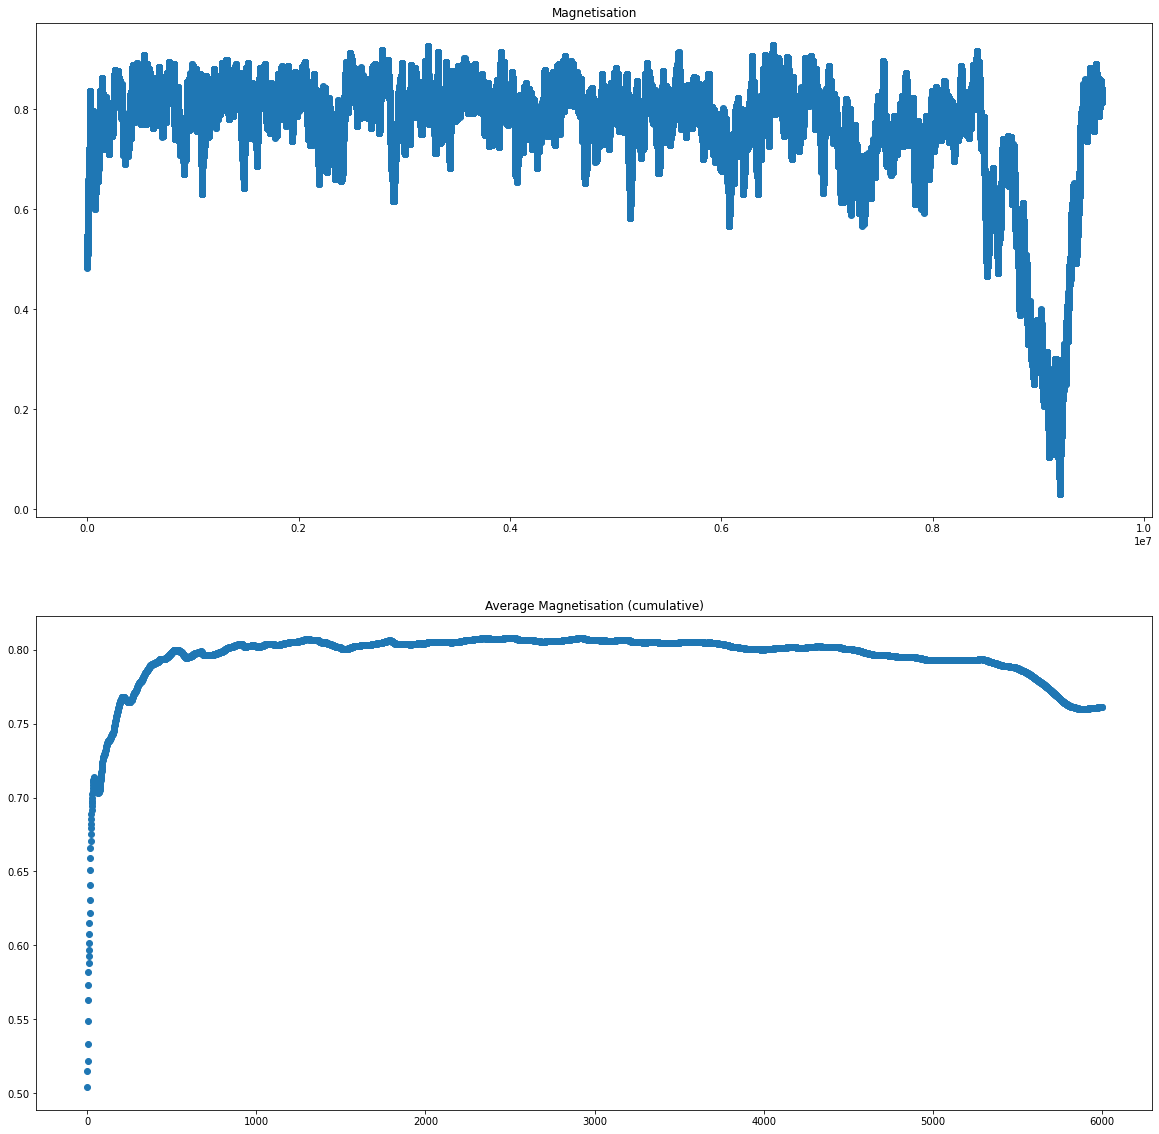

In [130]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20,20))

axs[0].set_title('Magnetisation')

axs[0].scatter(range(N_trials), m)

axs[1].set_title('Average Magnetisation (cumulative)')
axs[1].scatter(range(N_sweeps), avM)


In [110]:
100000/(model.N_spins)

62.5

##### Burn sweeps and number of measurements for 40x40

In [ ]:
# This is for 40x40

burn_sweeps = {
    2: 30,
    2.1: 30,
    2.15: 50,
    2.2:
    2.25:
    2.3:
    2.4:
    2.5:
    
}

# Method 1 - no 'runs', random config for every temperature

1. Pick T
2. Random up or down config
3. Converge to equilibrium (takes longer closer to critical T)
4. Do N_trails, taking a snapshot every N0 trials
5. Repeat for equal number of up/down configs
6. Repeat at every T


In [56]:
# total number of states in data is:

x = 0 # Pure Ising Model
L = 40 
N0 = 40 # number of trials to run between snapshots

temp_dict = { # temperature: burn_sweeps
    2.22: 30,
    2.23: 30,
    2.24: 30,
    2.25: 30,
    2.26: 30,
    2.27: 30,
    2.28: 30,
    2.29: 30,
    2.30: 30
}

def N_sweeps_(burn_sweeps): # number of sweeps after doing the burns
    return 1*burn_sweeps

ups = 1 # x2 doubles the total number of sweeps
downs = ups

In [57]:
model = Ising(shape=(L,L), J=1, x=0)

states = []
labels = []

t1 = time()
n = 0
for kT in temp_dict:
    
    burn_sweeps = temp_dict[kT]
    N_sweeps = N_sweeps_(burn_sweeps)
    N_trials = N_sweeps*model.N_spins

    N_measurements = round(N_trials/N0)
    
    for _ in range(ups):
        model.init_up() # randomise lattice (mostly up)
        _= model.run_N_sweeps(N=burn_sweeps, kT=kT) # converge
        for _ in range(N_measurements):
            model.run_N_trials(N=N0, kT=kT)
            states.append(model.take_snapshot())
            labels.append(kT)
        n+= burn_sweeps + N_sweeps
        
    for _ in range(ups):
        model.init_down() # randomise lattice (mostly down)
        _= model.run_N_sweeps(N=burn_sweeps, kT=kT) # converge
        for _ in range(N_measurements):
            model.run_N_trials(N=N0, kT=kT)
            states.append(model.take_snapshot())
            labels.append(kT)
        n+= burn_sweeps + N_sweeps

print(time() - t1)

print(str(n) + ' total sweeps')

18.818812131881714
1080 total sweeps


In [58]:
t1 = time()
X = flatten_states(np.array(states))
print(time() - t1)
y = np.array(labels)

0.1340019702911377


In [59]:
X.shape

(21600, 1600)

In [60]:
t1 = time()
m = m_from_states(X)
M_mean, M_errs, temperatures = mean_absolute(m, y)
print(time() - t1)

0.15697193145751953


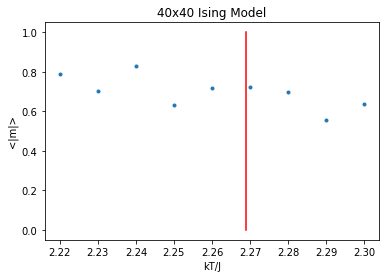

In [61]:
fig, ax = plt.subplots()

ax.set_title('40x40 Ising Model')
ax.set_xlabel('kT/J')
ax.set_ylabel('<|m|>')

ax.errorbar(temperatures, M_mean, yerr=M_errs, fmt='.', ecolor='red')
ax.plot([2.269, 2.269], [0,1], color='red')

In [62]:
t1 = time()
np.savetxt('data/binder_2/L=40_X.txt', X, fmt='%i')
np.savetxt('data/binder_2/L=40_y.txt', y, fmt='%1.5f')
print(time() - t1)

4.755099058151245


# Method 2

We're implementing the thing to not get stuck in local minima

200 sweeps seems to work for lower temperatures

4000 sweeps seems to work for around Tc

To get the right graph, I think u need to: find the mean magnetisation at each temperature.
Take the absolute of this mean.
Average these absolute means over the different runs

In [472]:
def absolute_mean(value, y, central_limit=True):
    temperatures = list(set(y))
    
    means = []
    errs = []
    for kT in temperatures:
        filt = y==kT
        samples = value[filt]
        N_samples = len(samples)
        mean = np.mean(samples)
        if central_limit:
            err = np.std(samples)/np.sqrt(N_samples)
        else:
            err = np.std(samples)
        
        errs.append(err)
        means.append(mean)
        
        abs_means = np.abs(means)
        
    return abs_means, errs, temperatures

In [475]:
def run(model, up: bool, N_sweeps, N_sweeps_around_crit, Tc=2.269):
    x = 0.4
    Tc = round(Tc, 1)
    Tstart = Tc - x
    Tbelow = [Tc - (n+6)*0.1 for n in range(5)]
    Tcrit = [Tc - (x - n) for n in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]]
    Thigh = [Tc + (n + 3)*0.1 for n in range(8)]
    
    Tstart = 1.7
    Tbelow = [1.6,1.5,1.4,1.3,1.2]
    Tabove = [1.8, 1.9]
    Tcrit = [2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3]
    Thigh = []
    
    if up:
        model.init_up()
    else:
        model.init_down()

    states = []
    labels = []
    
    states += model.run_N_sweeps(N=N_sweeps, kT=Tstart)
    labels += [Tstart for e in range(N_sweeps)]
    
    seed = model.take_snapshot()
    print(seed)
    
    for kT in Tbelow:
        states += model.run_N_sweeps(N=N_sweeps, kT=kT)
        labels += [kT for e in range(N_sweeps)]
        
    model.set_lattice(seed)
    
    for kT in Tabove:
        states += model.run_N_sweeps(N=N_sweeps, kT=kT)
        labels += [kT for e in range(N_sweeps)]
        
    for kT in Tcrit:
        states += model.run_N_sweeps(N=N_sweeps_around_crit, kT=kT)
        labels += [kT for e in range(N_sweeps_around_crit)]
        
    for kT in Thigh:
        states += model.run_N_sweeps(N=N_sweeps, kT=kT)
        labels += [kT for e in range(N_sweeps)]
        
    return states, labels

In [479]:
model = Ising(shape=(10,10), J=1)

t0 = time()

states = []
labels = []
for e in range(50):
    states_, labels_ = run(model, up=True, N_sweeps=10, N_sweeps_around_crit=20)
    states += states_
    labels += labels_
for e in range(50):
    states_, labels_ = run(model, up=False, N_sweeps=10, N_sweeps_around_crit=20)
    states += states_
    labels += labels_
    
print(time() - t0)

[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]
[[ 1  1  1  1 -1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1 -1 -1  1  1]
 [ 1  1  1  1  1 -1 -1 -1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]]
[[ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1 -1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1 -1 -1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]]
[[ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1 

 [ 1  1  1  1  1  1  1  1  1  1]]
[[ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1 -1 -1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1 -1  1  1  1  1  1  1  1]
 [ 1  1 -1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]]
[[ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1 -1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [-1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]]
[[ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1

 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]
[[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1  1 -1 -1 -1 -1 -1 -1 -1]]
[[-1 -1 -1 -1 -1 -1  1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]
[[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1  1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1

 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]
[[-1 -1 -1  1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1  1 -1 -1 -1 -1 -1]
 [-1  1  1 -1  1  1 -1 -1 -1 -1]
 [-1  1  1  1  1  1 -1 -1 -1 -1]
 [-1  1  1  1  1 -1 -1 -1 -1 -1]]
[[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1  1  1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]
[[ 1 -1 -1 -1 -1 -1 -1  1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1

In [ ]:
X = flatten_states(np.array(states))
y = np.array(states)

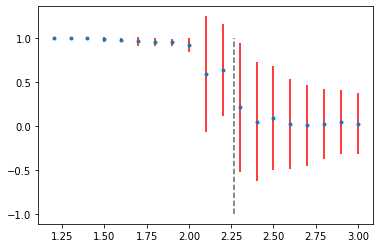

In [473]:
m = []
for state in X:
    mag = np.sum(state)/len(state)
    m.append(mag)
m = np.array(m)

M_mean, M_err, temperatures = absolute_mean(m, y, central_limit=False)
    
fig, ax = plt.subplots()

ax.errorbar(temperatures, M_mean, yerr=M_err, fmt='.', ecolor='red')
# ax.scatter(y, m, alpha=0.003)
ax.plot(np.repeat(2.2691, 121), np.linspace(-1, 1, 121), 'k--', alpha=0.6)

In [280]:
def convert_1(data): # shape of states: (n_runs, n_temps, n_states, dimension1, dimension2, ... )
    
    # concatenating the different runs then different temperatures
    data = np.concatenate(tuple(data))
    data = np.concatenate(tuple(data))
    
    return flatten_states(data)

In [235]:
initial_shape = ALL.shape

In [236]:
data = convert_to_training_data(ALL)

In [266]:
labels = [T for r in range(n_runs) for T in temperatures for _ in range(n_snapshots)]
labels = np.array(labels)

In [267]:
labels

array([1.6, 1.6, 1.6, ..., 3. , 3. , 3. ])

np.savetxt('data/method_2/ising_10x10.txt', data, fmt='%d')